--- LOF OPTIMIZAT PE GPU VIA PYTORCH (100K SAMPLES - 2018) ---
Dispozitiv detectat: cuda
Încărcare date din fișierele .pt...
Se extrage un eșantion de 100000 rânduri pentru antrenare...
Antrenare LOF în curs pe GPU...
Antrenare pe GPU finalizată în 1.11 secunde.
Generare rezultate via CUDA...

REZULTATE LOF GPU (OPTIMIZAT FN) - 2018
AUC: 0.9313
              precision    recall  f1-score   support

      Normal       0.85      0.84      0.84      7633
    Anomalie       0.95      0.95      0.95     22367

    accuracy                           0.92     30000
   macro avg       0.90      0.89      0.89     30000
weighted avg       0.92      0.92      0.92     30000



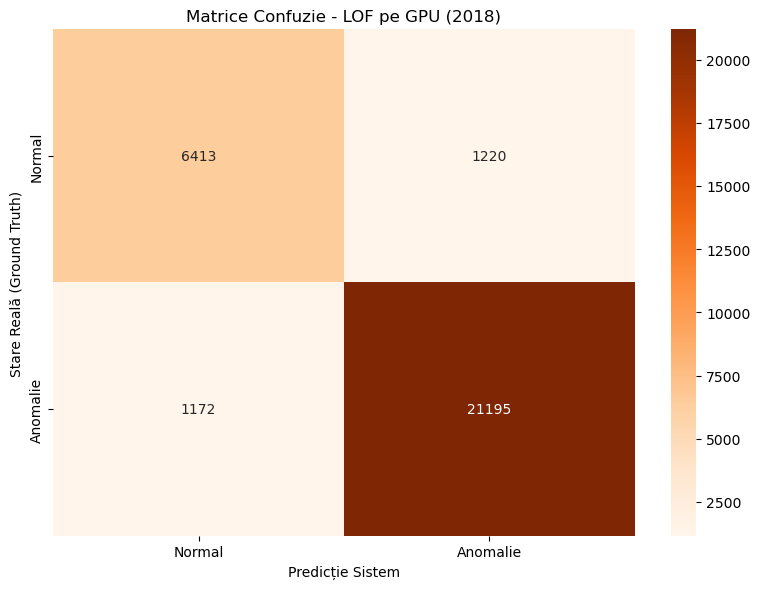

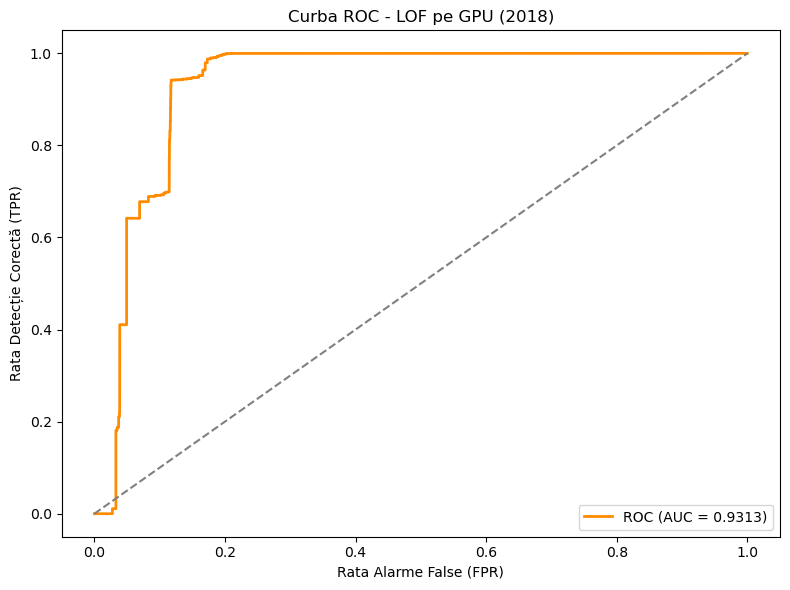

Model salvat în: D:\disertatie\modele_2018\LOF\model_lof_2018_100k_gpu.pkl
Graficele au fost salvate în: D:\disertatie\rezultate_2018\LOF


In [1]:
import sys
import os
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
import joblib
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc

data_path = r'D:\disertatie\preprocesare_anomalii_2018'
model_save_path = r'D:\disertatie\modele_2018\LOF'
rezultate_path = r'D:\disertatie\rezultate_2018\LOF'

for p in [model_save_path, rezultate_path]:
    os.makedirs(p, exist_ok=True)

print("--- LOF OPTIMIZAT PE GPU VIA PYTORCH (100K SAMPLES - 2018) ---")

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Dispozitiv detectat: {device}")

print("Încărcare date din fișierele .pt...")
X_train_full = torch.load(os.path.join(data_path, 'X_train_2018.pt'), map_location=device).float()
X_test_full = torch.load(os.path.join(data_path, 'X_test_2018.pt'), map_location=device).float()
y_test_full = torch.load(os.path.join(data_path, 'y_test_2018.pt'), map_location=device)

np.random.seed(42)
n_train = 100000
n_test = 30000

print(f"Se extrage un eșantion de {n_train} rânduri pentru antrenare...")
idx_train = np.random.choice(X_train_full.shape[0], n_train, replace=False)
X_train = X_train_full[idx_train]

idx_test = np.random.choice(X_test_full.shape[0], n_test, replace=False)
X_test = X_test_full[idx_test]
y_test_tensor = y_test_full[idx_test]

y_test_cpu = y_test_tensor.cpu().numpy()

def compute_knn_gpu(X_target, X_source, k):
    n_target = X_target.shape[0]
    n_source = X_source.shape[0]
    distances = torch.zeros((n_target, k), device=device)
    indices = torch.zeros((n_target, k), dtype=torch.long, device=device)
    
    batch_size = 5000
    for i in range(0, n_target, batch_size):
        end_i = min(i + batch_size, n_target)
        X_batch = X_target[i:end_i]
        dist_matrix = torch.cdist(X_batch, X_source, p=2)
        topk_dist, topk_idx = torch.topk(dist_matrix, k=k, largest=False, dim=1)
        distances[i:end_i] = topk_dist
        indices[i:end_i] = topk_idx
    return distances, indices

def fit_lof_gpu(X_train, k=50):
    dist_train, idx_train = compute_knn_gpu(X_train, X_train, k + 1)
    dist_train = dist_train[:, 1:]
    idx_train = idx_train[:, 1:]
    k_dist = dist_train[:, -1]
    n_samples = X_train.shape[0]
    lrd = torch.zeros(n_samples, device=device)
    
    batch_size = 5000
    for i in range(0, n_samples, batch_size):
        end_i = min(i + batch_size, n_samples)
        neighbors_idx = idx_train[i:end_i]
        neighbors_k_dist = k_dist[neighbors_idx]
        actual_dists = dist_train[i:end_i]
        reach_dists = torch.max(actual_dists, neighbors_k_dist)
        sum_reach_dist = torch.sum(reach_dists, dim=1)
        lrd[i:end_i] = k / (sum_reach_dist + 1e-10)
    return k_dist, lrd, X_train

def predict_lof_gpu(X_test, k_dist_train, lrd_train, X_train, k=50):
    dist_test, idx_test = compute_knn_gpu(X_test, X_train, k)
    n_test = X_test.shape[0]
    lrd_test = torch.zeros(n_test, device=device)
    
    batch_size = 5000
    for i in range(0, n_test, batch_size):
        end_i = min(i + batch_size, n_test)
        neighbors_idx = idx_test[i:end_i]
        neighbors_k_dist = k_dist_train[neighbors_idx]
        actual_dists = dist_test[i:end_i]
        reach_dists = torch.max(actual_dists, neighbors_k_dist)
        sum_reach_dist = torch.sum(reach_dists, dim=1)
        lrd_test[i:end_i] = k / (sum_reach_dist + 1e-10)
        
    lof_scores = torch.zeros(n_test, device=device)
    for i in range(0, n_test, batch_size):
        end_i = min(i + batch_size, n_test)
        neighbors_idx = idx_test[i:end_i]
        lrd_neighbors = lrd_train[neighbors_idx]
        lrd_self = lrd_test[i:end_i].unsqueeze(1)
        lof_scores[i:end_i] = torch.mean(lrd_neighbors / (lrd_self + 1e-10), dim=1)
    return -(lof_scores - 1.0)

start_time = time.time()
print("Antrenare LOF în curs pe GPU...")
k_dist_train, lrd_train, _ = fit_lof_gpu(X_train, k=50)
train_time = time.time() - start_time
print(f"Antrenare pe GPU finalizată în {train_time:.2f} secunde.")

print("Generare rezultate via CUDA...")
decision_scores_tensor = predict_lof_gpu(X_test, k_dist_train, lrd_train, X_train, k=50)
decision_scores = decision_scores_tensor.cpu().numpy()

percentila_dorita = 75 
prag_dinamic = np.percentile(decision_scores, percentila_dorita)
y_pred = [1 if x < prag_dinamic else 0 for x in decision_scores]

y_scores = -decision_scores 
fpr, tpr, _ = roc_curve(y_test_cpu, y_scores)
roc_auc = auc(fpr, tpr)

report = classification_report(y_test_cpu, y_pred, target_names=['Normal', 'Anomalie'])
full_report = f"REZULTATE LOF GPU (OPTIMIZAT FN) - 2018\nAUC: {roc_auc:.4f}\n{report}"
print("\n" + full_report)

with open(os.path.join(rezultate_path, 'raport_lof_100k_gpu.txt'), 'w') as f:
    f.write(full_report)

plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test_cpu, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges', xticklabels=['Normal', 'Anomalie'], yticklabels=['Normal', 'Anomalie'])
plt.ylabel('Stare Reală (Ground Truth)')
plt.xlabel('Predicție Sistem')
plt.title('Matrice Confuzie - LOF pe GPU (2018)')
plt.tight_layout()
plt.savefig(os.path.join(rezultate_path, 'matrice_lof_100k_gpu.png'), dpi=300)
plt.show()

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlabel('Rata Alarme False (FPR)')
plt.ylabel('Rata Detecție Corectă (TPR)')
plt.title('Curba ROC - LOF pe GPU (2018)')
plt.legend(loc="lower right")
plt.tight_layout()
plt.savefig(os.path.join(rezultate_path, 'roc_lof_100k_gpu.png'), dpi=300)
plt.show()

model_data = {
    'k_dist_train': k_dist_train,
    'lrd_train': lrd_train,
    'X_train': X_train,
    'k': 50
}
model_file = os.path.join(model_save_path, 'model_lof_2018_100k_gpu.pkl')
joblib.dump(model_data, model_file)

print(f"Model salvat în: {model_file}")
print(f"Graficele au fost salvate în: {rezultate_path}")